# MLP - Speech Emotion Recognition

The MLP is the baseline model. Features are averaged over the time axis into a single flat vector per clip, so the model sees no temporal information whatsoever. The goal is to establish a floor - any model that uses temporal structure should beat this.

## Imports

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import glob
import os
from tqdm import tqdm
from data_loader import load_features
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

## Config

All hyperparameters and constants in one place. Change things here.

In [33]:
DATASET_PATH = "Audio_Speech_Actors_01-24"
TEST_ACTORS  = {21, 22, 23, 24}   # 2M + 2F, fixed forever
RANDOM_SEED  = 6283
BATCH_SIZE   = 32
N_EPOCHS     = 100
LR           = 1e-3
DROPOUT      = 0.3

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

## Model

Four linear layers with ReLU activations and dropout between them. Input is 122 features (40 MFCC + 40 delta + 40 delta-delta + 1 ZCR + 1 RMS), output is 8 raw logits - one per emotion class.

No softmax on the output. `CrossEntropyLoss` applies it internally, adding it manually would apply it twice.

Dropout randomly zeros activations during training with probability `dropout_coeff`. This prevents the network from over-relying on any single neuron and is the main regularization tool on a dataset this small.

In [34]:
class Net(nn.Module):

    def __init__(self, dropout_coeff=0.3):
        super().__init__()
        self.fc1     = nn.Linear(122, 256)
        self.fc2     = nn.Linear(256, 128)
        self.fc3     = nn.Linear(128, 64)
        self.fc4     = nn.Linear(64, 8)
        self.dropout = nn.Dropout(dropout_coeff)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

## Data Loading

`load_features` loops over the `.npz` files, parses the RAVDESS filename to extract the emotion label and actor ID, loads the stored feature arrays, and returns a list of dicts.

`flatten=True` means features are averaged over the time axis - each clip becomes a single vector. This is the MLP-specific step. The CNN and LSTM will use `flatten=False` to preserve the time dimension.

In [35]:
feature_files = glob.glob(os.path.join(DATASET_PATH, "Actor_*", "*.npz"))
records = load_features(feature_files, flatten=True, return_gender=False)
print(f"Loaded {len(records)} records")

Loading data: 100%|██████████| 1440/1440 [00:01<00:00, 1103.36it/s]

Loaded 1440 records


## Train / Val / Test Split

Splits are done by actor, not by clip. If the same actor appears in both train and val, the model can learn to recognize the speaker's voice instead of the emotion. This is called leakage and produces inflated validation accuracy that does not generalize.

The test set is hardcoded and never used during training or hyperparameter tuning. Val is used to monitor generalization during development. Test is used once at the end for the final reported number.

Male and female actors are shuffled separately to ensure each split has an equal gender ratio.

In [36]:
# Test set
test_data = [r for r in records if r['actor_id'] in TEST_ACTORS]
x_test    = np.array([r['features'] for r in test_data])
y_test    = np.array([r['label']    for r in test_data])

# Remaining 20 actors
train_valid_data = [r for r in records if r['actor_id'] not in TEST_ACTORS]
uniq_actor_id    = np.unique([r['actor_id'] for r in train_valid_data])

# Gender-balanced shuffle
np.random.seed(RANDOM_SEED)
male_set   = [a for a in uniq_actor_id if a % 2 == 1]
female_set = [a for a in uniq_actor_id if a % 2 == 0]
np.random.shuffle(male_set)
np.random.shuffle(female_set)

val_actors   = set(male_set[:2]  + female_set[:2])   # 2M + 2F
train_actors = set(male_set[2:]  + female_set[2:])   # 8M + 8F

train_data = [r for r in train_valid_data if r['actor_id'] not in val_actors]
val_data   = [r for r in train_valid_data if r['actor_id'] in val_actors]

x_train = np.array([r['features'] for r in train_data])
y_train = np.array([r['label']    for r in train_data])
x_val   = np.array([r['features'] for r in val_data])
y_val   = np.array([r['label']    for r in val_data])

print(f"Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Val label distribution:   {np.bincount(y_val)}")

Train: 960 | Val: 240 | Test: 240
Train label distribution: [ 64 128 128 128 128 128 128 128]
Val label distribution:   [16 32 32 32 32 32 32 32]


## Normalization

Each feature is scaled to zero mean and unit variance. This is necessary because different features (e.g. MFCC coefficients vs RMS energy) live on very different scales - without normalization, large-valued features dominate the gradients.

Mean and std are computed on the training set only. The same values are then applied to val and test. Computing them on val or test would leak information about those sets into the preprocessing step.

In [37]:
def fit_normalizer(X):
    return X.mean(axis=0), X.std(axis=0)

def normalize(X, mean, std):
    return (X - mean) / (std + 1e-8)  # 1e-8 avoids division by zero

train_mean, train_std = fit_normalizer(x_train)

x_train_norm = normalize(x_train, train_mean, train_std)
x_val_norm   = normalize(x_val,   train_mean, train_std)
x_test_norm  = normalize(x_test,  train_mean, train_std)

## Tensors and DataLoaders

PyTorch operates on tensors, not numpy arrays. `dtype=torch.float32` for features and `dtype=torch.long` for labels - `CrossEntropyLoss` requires integer class indices.

`DataLoader` wraps the dataset and handles batching and shuffling. `shuffle=True` on train ensures the batch order changes every epoch. `shuffle=False` on val since order does not matter for evaluation.

In [38]:
x_train_torch = torch.tensor(x_train_norm, dtype=torch.float32)
y_train_torch = torch.tensor(y_train,      dtype=torch.long)
x_val_torch   = torch.tensor(x_val_norm,   dtype=torch.float32)
y_val_torch   = torch.tensor(y_val,        dtype=torch.long)
x_test_torch  = torch.tensor(x_test_norm,  dtype=torch.float32)
y_test_torch  = torch.tensor(y_test,       dtype=torch.long)

train_loader = DataLoader(TensorDataset(x_train_torch, y_train_torch), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_torch,   y_val_torch),   batch_size=BATCH_SIZE, shuffle=False)

## Training

Each epoch iterates over all batches in `train_loader`. For each batch:
1. `zero_grad` clears gradients from the previous batch - PyTorch accumulates them by default
2. Forward pass produces logits
3. Loss is computed against the true labels
4. `backward` computes gradients via backpropagation
5. `optimizer.step` updates the weights

`running_loss` accumulates the batch losses and is divided by the number of samples at the end of each epoch to get the average per-sample loss.

In [39]:
model     = Net(dropout_coeff=DROPOUT)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

loss_vector = []

model.train()
for epoch in range(N_EPOCHS):
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader.dataset)
    loss_vector.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/{N_EPOCHS}  loss: {avg_loss:.4f}")

print("Finished training")
torch.save(model.state_dict(), 'mlp_weights.pth')

Epoch  10/100  loss: 0.0259
Epoch  20/100  loss: 0.0093
Epoch  30/100  loss: 0.0048
Epoch  40/100  loss: 0.0032
Epoch  50/100  loss: 0.0024
Epoch  60/100  loss: 0.0015
Epoch  70/100  loss: 0.0020
Epoch  80/100  loss: 0.0022
Epoch  90/100  loss: 0.0018
Epoch 100/100  loss: 0.0012
Finished training


## Training Loss Curve

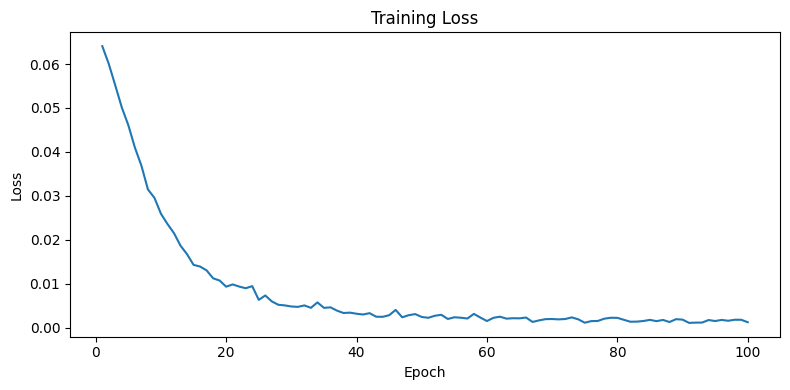

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, N_EPOCHS + 1), loss_vector)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.tight_layout()
plt.show()

## Validation

`model.eval()` switches off dropout so predictions are deterministic. `torch.no_grad()` disables gradient computation - not needed during evaluation and saves memory.

The classification report shows per-class precision, recall and F1. More informative than overall accuracy on an imbalanced dataset.

In [41]:
all_preds  = []
all_labels = []
correct    = 0
total      = 0

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(classification_report(all_labels, all_preds, target_names=list(EMOTION_MAP.values())))
print(f'Val accuracy: {100 * correct / total:.2f}%')

              precision    recall  f1-score   support

     neutral       0.09      0.12      0.11        16
        calm       0.59      0.41      0.48        32
       happy       0.41      0.50      0.45        32
         sad       0.18      0.25      0.21        32
       angry       0.76      0.59      0.67        32
     fearful       0.30      0.41      0.35        32
     disgust       0.27      0.12      0.17        32
   surprised       0.20      0.19      0.19        32

    accuracy                           0.34       240
   macro avg       0.35      0.32      0.33       240
weighted avg       0.37      0.34      0.34       240

Val accuracy: 33.75%
